1%
10%
50%


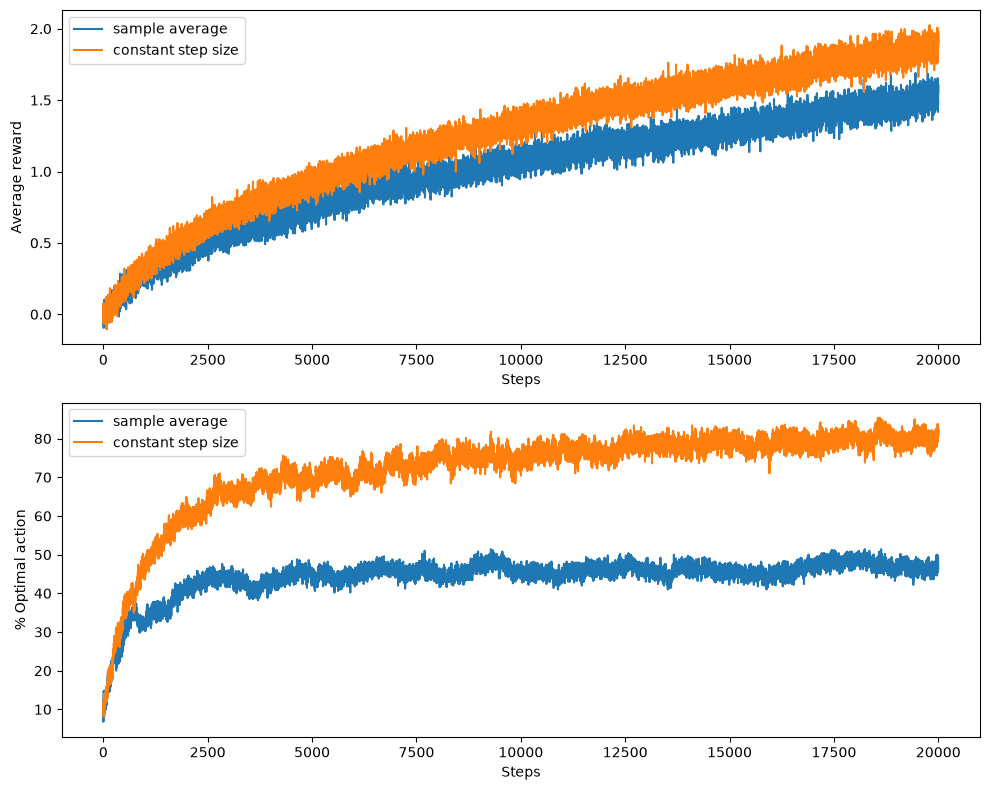

In [16]:
# Exercise 2.5: non-stationary 10-armed bandit
# Comparing sample average vs constant step size (alpha=0.1) on a non-stationary bandit where true rewards drift due to random walk (mean=0, std=0.01 per step).
# epsilon=0.1, 20000 steps, 200 runs.
# Result: Constant step size tracks changes better.
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
def bandit(actions, true_rewards):
    runs = np.arange(true_rewards.shape[0])
    rewards = np.random.normal(true_rewards[runs, actions], 1) 
    return rewards

def egreedy(true_rewards, runs, val_est, action_counts, epsilon):
    rows = np.arange(runs)
    explore = np.random.random(size = runs) < epsilon
    random_actions = np.random.randint(0, 10, size = runs)

    max_vals = val_est.max(axis = 1, keepdims = True)
    # if val_est is n x 3
    # max_vals = [[a],
    #             [b],
    #             [c]]

    best_actions = val_est == max_vals
    # if val_est is 3 x 3
    # best_actions = [[x1_1 == a, x1_2 == a, x1_3 == a],
    #                 [x2_1 == b, x2_2 == b, x2_3 == b],
    #                 [x3_1 == c, x3_2 == c, x3_3 == c]]
    # a matrix where each row the best actions = True

    rand = np.random.random(best_actions.shape)
    # random = [[0.2, 0.9, 0.3],
    #           [0.1, 0.4, 0.5],
    #           [0.5, 0.3, 0.6]]

    rand[~best_actions] = -1
    # ~best_actions is best_actions where every element = !element
    # so ~best_actions is a matrix where each row the actions that arent the best = True
    # random[~best_actions] = -1 gets every element in random where ~best_actions is True, and sets them to -1

    greedy_actions = np.argmax(rand, axis = 1)

    actions = np.where(explore, random_actions, greedy_actions)

    rewards = bandit(actions, true_rewards)

    action_counts[rows, actions] += 1
    val_est[rows, actions] = val_est[rows, actions] + (1/action_counts[rows, actions]) * (rewards - val_est[rows, actions])
    optimal_actions = np.argmax(true_rewards, axis=1)
    optimals = (actions == optimal_actions).astype(int)
    optimals *= 100
    return rewards, optimals


def agreedy(true_rewards, runs, val_est , action_counts, epsilon, step_size):
    rows = np.arange(runs)
    explore = np.random.random(size = runs) < epsilon
    random_actions = np.random.randint(0, 10, size = runs)
    max_vals = val_est.max(axis = 1, keepdims = True)
    best_actions = val_est == max_vals
    rand = np.random.random(best_actions.shape)
    rand[~best_actions] = -1
    greedy_actions = np.argmax(rand, axis = 1)
    actions = np.where(explore, random_actions, greedy_actions)
    rewards = bandit(actions, true_rewards)
    action_counts[rows, actions] += 1
    val_est[rows, actions] = val_est[rows, actions] + step_size * (rewards - val_est[rows, actions])
    optimal_actions = np.argmax(true_rewards, axis=1)
    optimals = (actions == optimal_actions).astype(int)
    optimals *= 100
    return rewards, optimals

def main():
    

    steps = 20000
    runs = 500
    epsilon = 0.1
    constant_step_size = 0.1
    egreedy_avg_rewards = np.zeros((runs, steps))
    egreedy_avg_optimals = np.zeros((runs, steps))
    agreedy_avg_rewards = np.zeros((runs, steps))
    agreedy_avg_optimals = np.zeros((runs, steps))
    agreedy_avg_optimals = np.zeros((runs, steps))
    rows = np.arange(runs)
    true_rewards  = np.zeros((runs, 10))
    
    egreedy_val_est = np.zeros((runs, 10))
    egreedy_action_counts = np.zeros((runs, 10))
    agreedy_val_est = np.zeros((runs, 10))
    agreedy_action_counts = np.zeros((runs, 10))    

    for step in range(1, steps + 1):
        egreedy_step_rewards, egreedy_step_optimals = egreedy(true_rewards, runs, egreedy_val_est, egreedy_action_counts, epsilon)
        agreedy_step_rewards, agreedy_step_optimals = agreedy(true_rewards, runs, agreedy_val_est, agreedy_action_counts, epsilon, constant_step_size)

        egreedy_avg_rewards[rows, step - 1] = egreedy_step_rewards
        egreedy_avg_optimals[rows, step - 1] = egreedy_step_optimals

        agreedy_avg_rewards[rows, step - 1] = agreedy_step_rewards
        agreedy_avg_optimals[rows, step - 1] = agreedy_step_optimals
        
        true_rewards += np.random.normal(0, 0.01, size=true_rewards.shape)
        if step == 200:
            print("1%")
        if step == 2000:
            print("10%")
        if step == 10000:
            print("50%")

    egreedy_avg_rewards = egreedy_avg_rewards.mean(axis = 0)
    egreedy_avg_optimals = egreedy_avg_optimals.mean(axis = 0)

    agreedy_avg_rewards = agreedy_avg_rewards.mean(axis = 0)
    agreedy_avg_optimals = agreedy_avg_optimals.mean(axis = 0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(egreedy_avg_rewards, label='sample average')
    ax1.plot(agreedy_avg_rewards, label='constant step size')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Average reward')
    ax1.legend()

    ax2.plot(egreedy_avg_optimals, label='sample average')
    ax2.plot(agreedy_avg_optimals, label='constant step size')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('% Optimal action')
    ax2.legend()

    plt.tight_layout()
    plt.show()

main()

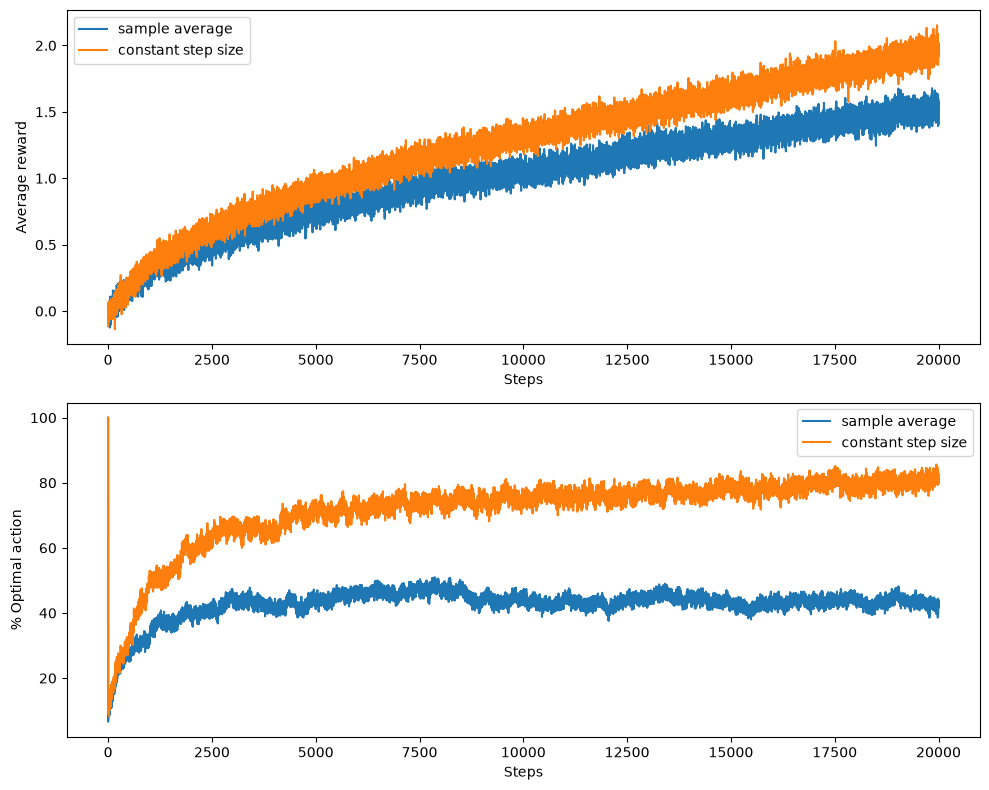

In [17]:
# Exercise 2.5: non-stationary 10-armed bandit
# Comparing sample average vs constant step size (alpha=0.1) on a non-stationary bandit where true rewards drift due to random walk (mean=0, std=0.01 per step).
# epsilon=0.1, 20000 steps, 200 runs.
# Result: Constant step size tracks changes better.
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
def bandit(action, true_rewards):
    reward = np.random.normal(true_rewards[action],1)
    return reward

def sample_average(true_rewards,value_estimates,action_chosen,epsilon,steps,rewards,optimal_choice):
    if np.random.random() < epsilon:
        index = np.random.randint(0,10)
        action = index
    else:
        greediest_value = np.max(value_estimates)
        greedy_actions = []
        for action, value in enumerate(value_estimates):
            if value == greediest_value:
                greedy_actions.append(action)
        action = np.random.choice(greedy_actions)
    reward = bandit(action,true_rewards)
    action_chosen[action] += 1
    value_estimates[action] = value_estimates[action] + (1/action_chosen[action]) * (reward - value_estimates[action])
    rewards.append(reward)
    if true_rewards[action] == np.max(true_rewards):
        optimal_choice.append(100)
    else:
        optimal_choice.append(0)

def step_size(true_rewards,value_estimates,action_chosen,epsilon,step_size,steps,rewards,optimal_choice):
    if np.random.random() < epsilon:
        index = np.random.randint(0,10)
        action = index
    else:
        greediest_value = np.max(value_estimates)
        greedy_actions = []
        for action, value in enumerate(value_estimates):
            if value == greediest_value:
                greedy_actions.append(action)
        action = np.random.choice(greedy_actions)
    reward = bandit(action,true_rewards)
    action_chosen[action] += 1
    value_estimates[action] = value_estimates[action] + step_size * (reward - value_estimates[action])
    rewards.append(reward)
    if true_rewards[action] == np.max(true_rewards):
        optimal_choice.append(100)
    else:
        optimal_choice.append(0)

def main():
    

    steps = 20000
    runs = 500
    avg_rewards = np.zeros(steps)
    optimal_pct = np.zeros(steps)
    avg_rewards_alt = np.zeros(steps)
    optimal_pct_alt = np.zeros(steps)
    
    for run in range(1, runs + 1):
        true_rewards  = [0,0,0,0,0,0,0,0,0,0]
        value_estimates = [0,0,0,0,0,0,0,0,0,0]
        action_chosen = [0,0,0,0,0,0,0,0,0,0]
        alt_value_estimates = [0,0,0,0,0,0,0,0,0,0]
        alt_action_chosen = [0,0,0,0,0,0,0,0,0,0]
        rewards = []
        optimal_choice = []
        alt_rewards = []
        alt_optimal_choice = []
        for step in range(1,steps + 1):
            sample_average(true_rewards,value_estimates,action_chosen,0.1,1,rewards,optimal_choice)
            step_size(true_rewards,alt_value_estimates,alt_action_chosen,0.1,0.1,1, alt_rewards,alt_optimal_choice)
            for reward in range(10):
                true_rewards[reward] += np.random.normal(0,.01)
        avg_rewards += rewards
        optimal_pct += optimal_choice
        avg_rewards_alt += alt_rewards
        optimal_pct_alt += alt_optimal_choice
    avg_rewards /= runs
    optimal_pct /= runs
    avg_rewards_alt /= runs
    optimal_pct_alt /= runs

    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(avg_rewards, label='sample average')
    ax1.plot(avg_rewards_alt, label='constant step size')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Average reward')
    ax1.legend()

    ax2.plot(optimal_pct, label='sample average')
    ax2.plot(optimal_pct_alt, label='constant step size')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('% Optimal action')
    ax2.legend()

    plt.tight_layout()
    plt.show()

main()